In [16]:
import tensorflow as tf
from pathlib import Path

base_dir = Path.cwd()

train_dir = Path(base_dir) / "dataset" / "Train_preprocessed"
test_dir = Path(base_dir) / "dataset" / "Test_preprocessed"
h, w = 224, 224

train = tf.keras.utils.image_dataset_from_directory(
    train_dir, color_mode="grayscale", seed=42, image_size=(h, w), batch_size=32, label_mode="int"
)
val = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", color_mode="grayscale", seed=42, image_size=(h, w), batch_size=32, label_mode="int"
)
test = tf.keras.utils.image_dataset_from_directory(
    test_dir, color_mode="grayscale", seed=42, image_size=(h, w), batch_size=32, label_mode="int"
)

AUTOTUNE = tf.data.AUTOTUNE
train = train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val = val.cache().prefetch(buffer_size=AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [17]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 1)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    
    tf.keras.layers.Dense(4, activation="softmax")
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,880,260 (49.13 MB)

 Trainable params: 12,879,492 (49.13 MB)

 Non-trainable params: 768 (3.00 KB)

In [18]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(train, validation_data=val, epochs=20, callbacks=[early_stopping_cb])

Epoch 1/20


c:\Users\Adisa Teslim\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 98ms/step - accuracy: 0.7577 - loss: 0.6359 - val_accuracy: 0.7152 - val_loss: 0.7114
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.8679 - loss: 0.3694 - val_accuracy: 0.8973 - val_loss: 0.2909
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.9154 - loss: 0.2417 - val_accuracy: 0.9098 - val_loss: 0.2678
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.9400 - loss: 0.1762 - val_accuracy: 0.8813 - val_loss: 0.2902
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.9613 - loss: 0.1267 - val_accuracy: 0.9259 - val_loss: 0.2012
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.9663 - loss: 0.1035 - val_accuracy: 0.6375 - val_loss: 1.0459
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.9746 - loss: 0.0772 - val_accuracy: 0.9688 - val_loss: 0.0906
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.9802 - loss: 0.0621 - val_accurac

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(y_test, y_pred, model_name, class_names):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Brain Tumor CLF Confusion Matrix')
    plt.show()

Classification Report
{'glioma': {'precision': 0.778393351800554, 'recall': 0.7025, 'f1-score': 0.7385019710906702, 'support': 400.0}, 'meningioma': {'precision': 0.8058968058968059, 'recall': 0.82, 'f1-score': 0.8128872366790583, 'support': 400.0}, 'no_tumor': {'precision': 0.9002320185614849, 'recall': 0.97, 'f1-score': 0.9338146811070999, 'support': 400.0}, 'pituitary': {'precision': 0.885286783042394, 'recall': 0.8875, 'f1-score': 0.8863920099875156, 'support': 400.0}, 'accuracy': 0.845, 'macro avg': {'precision': 0.8424522398253098, 'recall': 0.845, 'f1-score': 0.842898974716086, 'support': 1600.0}, 'weighted avg': {'precision': 0.8424522398253097, 'recall': 0.845, 'f1-score': 0.842898974716086, 'support': 1600.0}}


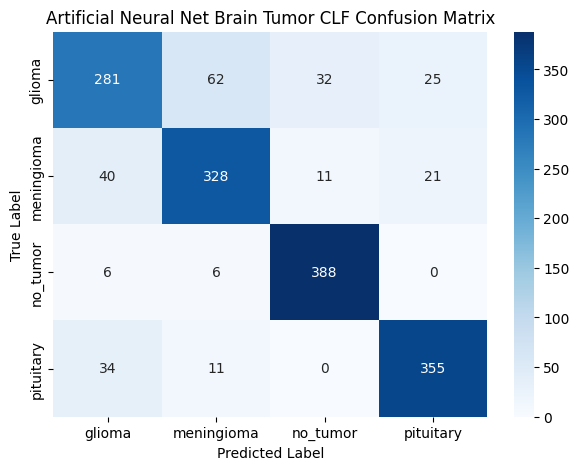

Macro-Averaged ROC-AUC: 0.9521


In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

y_true_batches = []
y_prob_batches = []

for images, labels in test:
    probs = model(images, training=False).numpy()
    labels = labels.numpy()

    # Handles either integer labels or one-hot labels.
    if labels.ndim > 1:
        labels = np.argmax(labels, axis=1)
    else:
        labels = labels.reshape(-1)

    y_prob_batches.append(probs)
    y_true_batches.append(labels)

y_prob = np.concatenate(y_prob_batches, axis=0)
y_true = np.concatenate(y_true_batches, axis=0).astype(int)
y_pred = np.argmax(y_prob, axis=1)

class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]

report_dict = classification_report(y_true, y_pred, target_names=class_names, digits=4, output_dict=True)
print("Classification Report")
print(report_dict)

plot_cm(y_true, y_pred, "Artificial Neural Net", class_names)

auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
print(f"Macro-Averaged ROC-AUC: {auc:.4f}")

report_dict['roc_auc'] = {'macro_avg_score': auc}
df_report = pd.DataFrame(report_dict).transpose()
output_dir = base_dir / "results" / "artificial_neural_network_results.csv"

df_report.to_csv(output_dir)